In [ ]:
!pip install gensim
!pip install jax==0.7.2
!pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 62.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.callbacks import EarlyStopping

import gensim.downloader as api

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
df = pd.read_csv('/content/Book_review.csv')

In [ ]:
df.head()

,Unnamed: 0,rating,reviewText,summary
0,0,5,This book was the very first bookmobile book I...,50 + years ago...
1,1,1,"When I read the description for this book, I c...",Boring! Boring! Boring!
2,2,5,I just had to edit this review. This book is a...,Wiggleliscious/new toy ready/!!
3,3,5,I don't normally buy 'mystery' novels because ...,Very good read.
4,4,5,"This isn't the kind of book I normally read, a...",Great Story!


In [ ]:
print(df.shape)
print(df.columns)

(12000, 4)
Index(['Unnamed: 0', 'rating', 'reviewText', 'summary'], dtype='object')


In [ ]:
df = df[['reviewText', 'rating']]

In [ ]:
df.columns = ['review', 'rating']

In [ ]:
df = df[df['rating'] != 3]

In [ ]:
df['sentiment'] = df['rating'].apply(lambda x: 1 if x >= 4 else 0)

In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
1,6000
0,4000


In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()

    cleaned_words = []

    for word in words:

        if word not in stop_words:

            word = lemmatizer.lemmatize(word)

            cleaned_words.append(word)

    return ' '.join(cleaned_words)

In [ ]:
df['clean_review'] = df['review'].apply(clean_text)

In [ ]:
df[['review', 'clean_review']].head()

,review,clean_review
0,This book was the very first bookmobile book I...,book first bookmobile book bought school book ...
1,"When I read the description for this book, I c...",read description book couldnt wait read downlo...
2,I just had to edit this review. This book is a...,edit review book believe got right updated rew...
3,I don't normally buy 'mystery' novels because ...,dont normally buy mystery novel dont like howe...
4,"This isn't the kind of book I normally read, a...",isnt kind book normally read although try limi...


In [ ]:
max_words = 10000

tokenizer = Tokenizer(num_words=max_words)

tokenizer.fit_on_texts(df['clean_review'])

sequences = tokenizer.texts_to_sequences(df['clean_review'])

In [ ]:
sequence_lengths = [len(seq) for seq in sequences]

max_len = int(np.percentile(sequence_lengths, 95))

padded_sequences = pad_sequences(
    sequences,
    maxlen=max_len,
    padding='post'
)

print(max_len)

165


In [ ]:
X = padded_sequences
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
model_rnn = Sequential()

model_rnn.add(
    Embedding(
        input_dim=max_words,
        output_dim=128,
        input_length=max_len
    )
)

model_rnn.add(SimpleRNN(64))

model_rnn.add(Dropout(0.5))

model_rnn.add(Dense(1, activation='sigmoid'))

model_rnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_rnn = model_rnn.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 105ms/step - accuracy: 0.5772 - loss: 0.6825 - val_accuracy: 0.6125 - val_loss: 0.6683
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.6034 - loss: 0.6699 - val_accuracy: 0.6119 - val_loss: 0.6660
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - accuracy: 0.6048 - loss: 0.6690 - val_accuracy: 0.6094 - val_loss: 0.6700
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.6003 - loss: 0.6690 - val_accuracy: 0.6112 - val_loss: 0.6694
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - accuracy: 0.6086 - loss: 0.6594 - val_accuracy: 0.6112 - val_loss: 0.6675


In [ ]:
rnn_pred = model_rnn.predict(X_test)

rnn_pred = (rnn_pred > 0.5).astype(int)

print(accuracy_score(y_test, rnn_pred))

print(classification_report(y_test, rnn_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
0.5955
              precision    recall  f1-score   support

           0       0.29      0.01      0.01       800
           1       0.60      0.99      0.75      1200

    accuracy                           0.60      2000
   macro avg       0.44      0.50      0.38      2000
weighted avg       0.47      0.60      0.45      2000



In [ ]:
model_lstm = Sequential()

model_lstm.add(
    Embedding(
        input_dim=max_words,
        output_dim=128,
        input_length=max_len
    )
)

model_lstm.add(LSTM(64))

model_lstm.add(Dropout(0.5))

model_lstm.add(Dense(1, activation='sigmoid'))

model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_lstm = model_lstm.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 26s 233ms/step - accuracy: 0.5953 - loss: 0.6767 - val_accuracy: 0.6125 - val_loss: 0.6691
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 222ms/step - accuracy: 0.5966 - loss: 0.6749 - val_accuracy: 0.6125 - val_loss: 0.6662
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 218ms/step - accuracy: 0.5986 - loss: 0.6712 - val_accuracy: 0.6125 - val_loss: 0.6661


In [ ]:
lstm_pred = model_lstm.predict(X_test)

lstm_pred = (lstm_pred > 0.5).astype(int)

print(accuracy_score(y_test, lstm_pred))

print(classification_report(y_test, lstm_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step
0.6
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       800
           1       0.60      1.00      0.75      1200

    accuracy                           0.60      2000
   macro avg       0.30      0.50      0.38      2000
weighted avg       0.36      0.60      0.45      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
embedding_model = api.load('glove-wiki-gigaword-50')

[==================================================] 100.0% 66.0/66.0MB downloaded


In [ ]:
word_index = tokenizer.word_index

vocab_size = min(max_words, len(word_index) + 1)

embedding_dim = 50

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in word_index.items():

    if i < vocab_size:

        if word in embedding_model:

            embedding_matrix[i] = embedding_model[word]

In [ ]:
model_w2v = Sequential()

model_w2v.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=False
    )
)

model_w2v.add(LSTM(64))

model_w2v.add(Dropout(0.5))

model_w2v.add(Dense(1, activation='sigmoid'))

model_w2v.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_w2v.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 500,000 (1.91 MB)

In [ ]:
history_w2v = model_w2v.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 112ms/step - accuracy: 0.5952 - loss: 0.6789 - val_accuracy: 0.6137 - val_loss: 0.6656
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 19s 101ms/step - accuracy: 0.6012 - loss: 0.6697 - val_accuracy: 0.6169 - val_loss: 0.6629
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.6036 - loss: 0.6676 - val_accuracy: 0.6156 - val_loss: 0.6603
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - accuracy: 0.6153 - loss: 0.6595 - val_accuracy: 0.6162 - val_loss: 0.6635
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step - accuracy: 0.6080 - loss: 0.6654 - val_accuracy: 0.6137 - val_loss: 0.6637
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - accuracy: 0.6005 - loss: 0.6682 - val_accuracy: 0.6137 - val_loss: 0.6601
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.6016 - loss: 0.6661 - val_accuracy: 0.6062 - val_loss: 0.6740
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - accuracy: 0.5978 - loss: 0.6710

In [ ]:
w2v_pred = model_w2v.predict(X_test)

w2v_pred = (w2v_pred > 0.5).astype(int)

print(accuracy_score(y_test, w2v_pred))

print(classification_report(y_test, w2v_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step
0.6045
              precision    recall  f1-score   support

           0       0.85      0.01      0.03       800
           1       0.60      1.00      0.75      1200

    accuracy                           0.60      2000
   macro avg       0.72      0.51      0.39      2000
weighted avg       0.70      0.60      0.46      2000



In [ ]:
def predict_sentiment(text):

    text = clean_text(text)

    seq = tokenizer.texts_to_sequences([text])

    padded = pad_sequences(
        seq,
        maxlen=max_len,
        padding='post'
    )

    prediction = model_w2v.predict(padded)[0][0]

    if prediction >= 0.5:

        print('Positive Review')

    else:

        print('Negative Review')

predict_sentiment('This book was absolutely amazing and emotional')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Positive Review


## Model Training History Visualizations

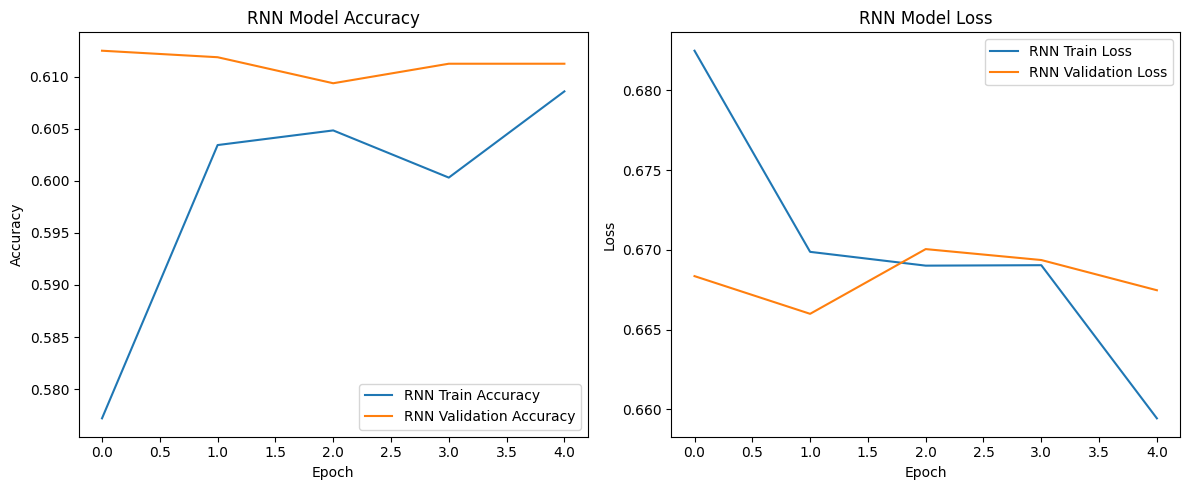

In [ ]:
plt.figure(figsize=(12, 5))

# Plotting RNN Model Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_rnn.history['accuracy'], label='RNN Train Accuracy')
plt.plot(history_rnn.history['val_accuracy'], label='RNN Validation Accuracy')
plt.title('RNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plotting RNN Model Loss
plt.subplot(1, 2, 2)
plt.plot(history_rnn.history['loss'], label='RNN Train Loss')
plt.plot(history_rnn.history['val_loss'], label='RNN Validation Loss')
plt.title('RNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

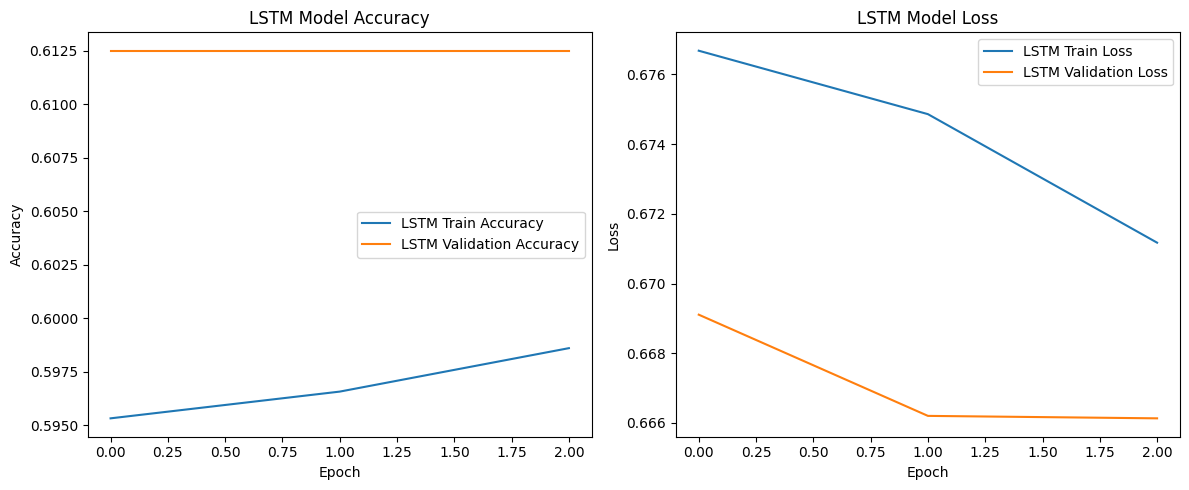

In [ ]:
plt.figure(figsize=(12, 5))

# Plotting LSTM Model Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['accuracy'], label='LSTM Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Validation Accuracy')
plt.title('LSTM Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plotting LSTM Model Loss
plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['loss'], label='LSTM Train Loss')
plt.plot(history_lstm.history['val_loss'], label='LSTM Validation Loss')
plt.title('LSTM Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

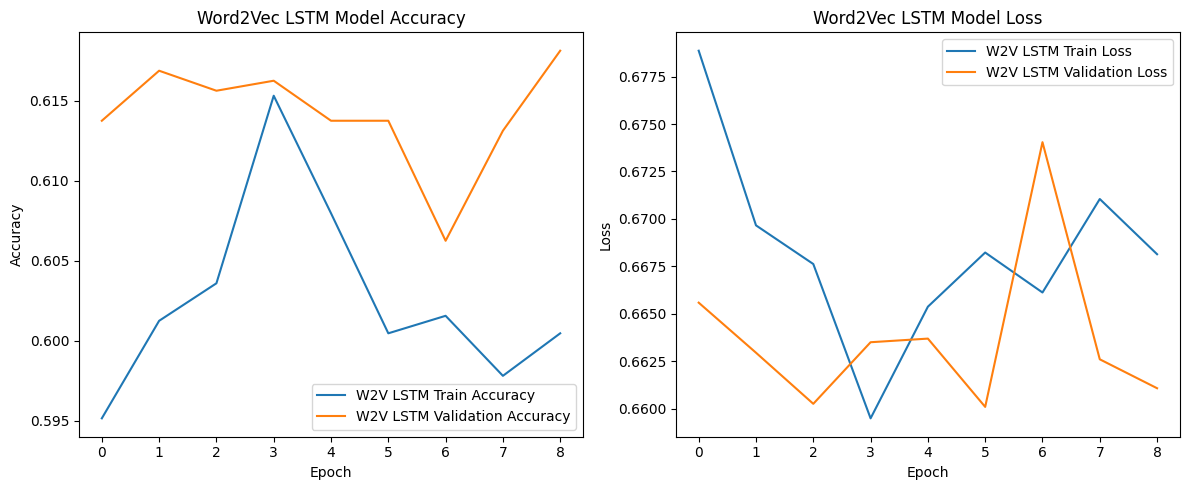

In [ ]:
plt.figure(figsize=(12, 5))

# Plotting Word2Vec LSTM Model Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_w2v.history['accuracy'], label='W2V LSTM Train Accuracy')
plt.plot(history_w2v.history['val_accuracy'], label='W2V LSTM Validation Accuracy')
plt.title('Word2Vec LSTM Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plotting Word2Vec LSTM Model Loss
plt.subplot(1, 2, 2)
plt.plot(history_w2v.history['loss'], label='W2V LSTM Train Loss')
plt.plot(history_w2v.history['val_loss'], label='W2V LSTM Validation Loss')
plt.title('Word2Vec LSTM Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Confusion Matrix Visualizations

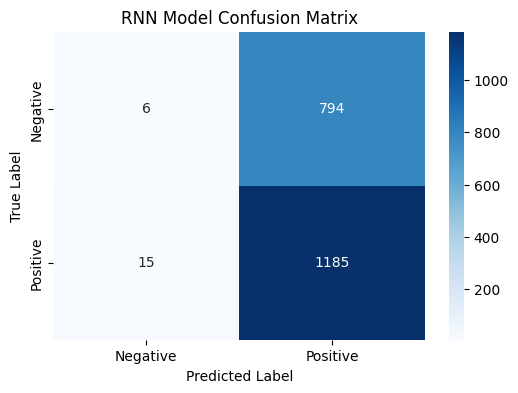

In [ ]:
cm_rnn = confusion_matrix(y_test, rnn_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_rnn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)
plt.title('RNN Model Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

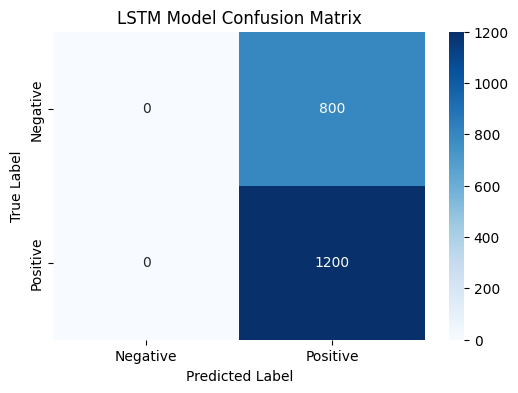

In [ ]:
cm_lstm = confusion_matrix(y_test, lstm_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_lstm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)
plt.title('LSTM Model Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

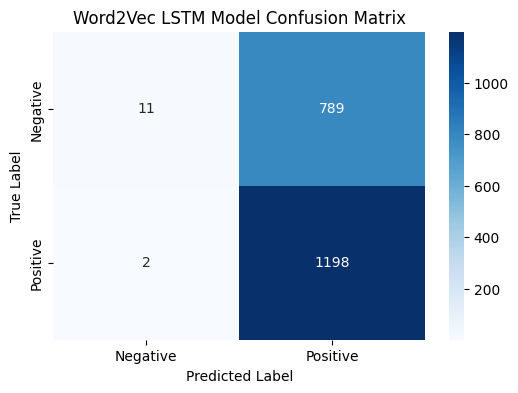

In [ ]:
cm_w2v = confusion_matrix(y_test, w2v_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_w2v,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)
plt.title('Word2Vec LSTM Model Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()